In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r"C:\Users\Soumik Ghosh\Desktop\great lakes\spotify_churn_dataset.csv")
data


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


## Exploring the dataset

In [4]:
data.info()
# no missing value is there.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


## Description of the dataset
offline_listening and is_churned is already encoded categorical variables. The others are mentioned in the above cell.

In [5]:
data.drop(columns=['user_id']).describe().T
# skip rate is expressed as percentage, (user_id ) being categorical variable doesnt add much to our analysis. No missing values is needed, a typically cleaned dataset.

,count,mean,std,min,25%,50%,75%,max
age,8000.0,37.662125,12.740359,16.0,26.00,38.0,49.00,59.0
listening_time,8000.0,154.068250,84.015596,10.0,81.00,154.0,227.00,299.0
songs_played_per_day,8000.0,50.127250,28.449762,1.0,25.00,50.0,75.00,99.0
skip_rate,8000.0,0.300127,0.173594,0.0,0.15,0.3,0.45,0.6
ads_listened_per_week,8000.0,6.943875,13.617953,0.0,0.00,0.0,5.00,49.0
offline_listening,8000.0,0.747750,0.434331,0.0,0.00,1.0,1.00,1.0
is_churned,8000.0,0.258875,0.438044,0.0,0.00,0.0,1.00,1.0


In [6]:
data.describe(include = object).T

,count,unique,top,freq
gender,8000,3,Male,2691
country,8000,8,AU,1034
subscription_type,8000,4,Premium,2115
device_type,8000,3,Desktop,2778


**Inference**
1. Most of the customer are male listening on desktop with a premium subscription and hailing from AU.
2. Mostly, young aged people are engaged in using it as depicted by the mean age of 38.
3. Those who listen spend a considerable time doing it since the 25% of the data from listening time is above 1 hr.
4. The product floated is quite engaging as the skip rate is around 30% among all the users.


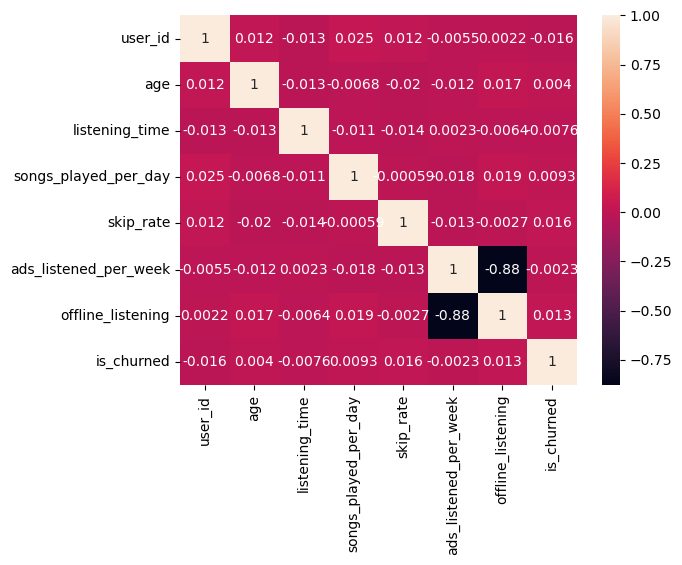

In [7]:
sns.heatmap(data.corr(numeric_only=True),annot = True)
plt.show()

*inference*
* Age as increases , decreases the listening time and skip rate.
* As listeners enthusiastic with the higher number of songs played is described often engage in offline listening. Although the correlation among the variables are lower, but comparatively higher in this dataset.

In [8]:
# separating num and cat columns
num_cols = ['age','listening_time','songs_played_per_day', 'skip_rate', 'ads_listened_per_week' ]
cat_cols = ['is_churned','offline_listening']

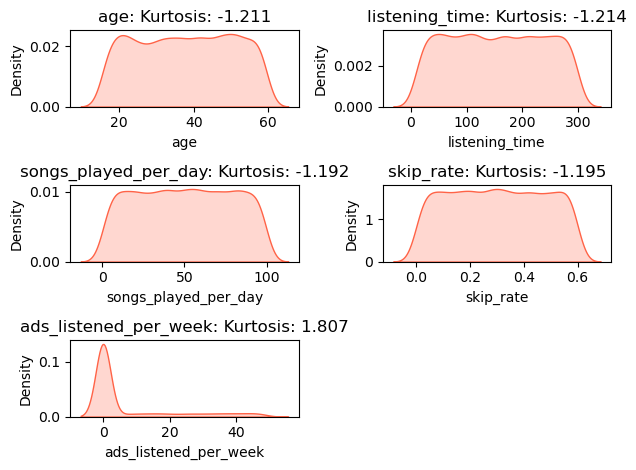

In [9]:
t = 1
for i in num_cols:
    plt.subplot(3,2,t)
    sns.kdeplot(data = data,x =i, fill = True, color = 'tomato')
    kurt= data[i].kurtosis()
    plt.title(f'{i}: Kurtosis: {round(kurt,3)}')
    
    t += 1
plt.tight_layout()
plt.show()
# the skewness for ads_listened peer week is skewed and hence needs preprocessing. We will use log 1p transformation for the same. 

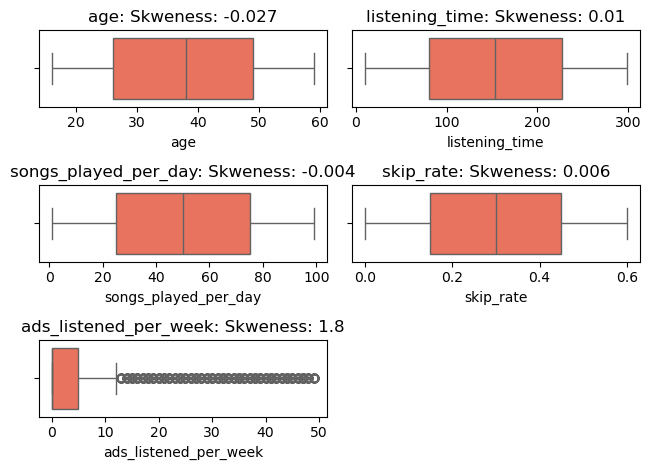

In [10]:
t = 1
for i in num_cols:
    plt.subplot(3,2,t)
    sns.boxplot(data = data,x =i, fill = True, color = 'tomato')
    skew= data[i].skew()
    plt.title(f'{i}: Skweness: {round(skew,3)}')
    t += 1
plt.tight_layout()
plt.show()

*inference*
* sings are listened across all age group and spotify is favourite among all ages as significant with its uniform distribution.
* Ads are not listened by many significant with its right skewed distribution.
* skip_rate and all other numerical columns follow a uniform distribution.

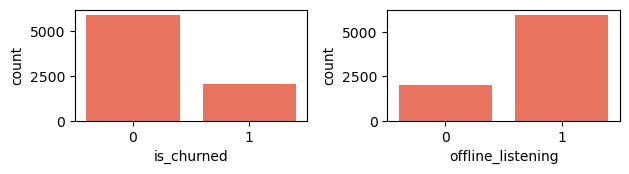

In [11]:
t = 1
for i in cat_cols:
    plt.subplot(3,2,t)
    sns.countplot(data = data,x =i, fill = True, color = 'tomato')
    
    t += 1
plt.tight_layout()
plt.show()
# The churning rate in the dataset is more than 50% of the data, while most of the customers in the database prefers offline listening.

In [12]:
data['subscription_type'].unique()

array(['Free', 'Family', 'Premium', 'Student'], dtype=object)

In [13]:
data['device_type'].unique()

array(['Desktop', 'Web', 'Mobile'], dtype=object)

In [14]:
data['gender'].unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [15]:
q3,q1 = data['ads_listened_per_week'].quantile([0.75,0.25])
iqr = 1.5*(q3 - q1)
ll,ul = q1 - iqr,q3 + iqr
data['ads_listened_per_week'] = data['ads_listened_per_week'].apply(lambda x: ul if x>ul else ll if x<ll else x)

In [16]:
data['ads_listened_per_week'].max(),data['ads_listened_per_week'].min()

(12.5, 0.0)

<Axes: xlabel='ads_listened_per_week'>

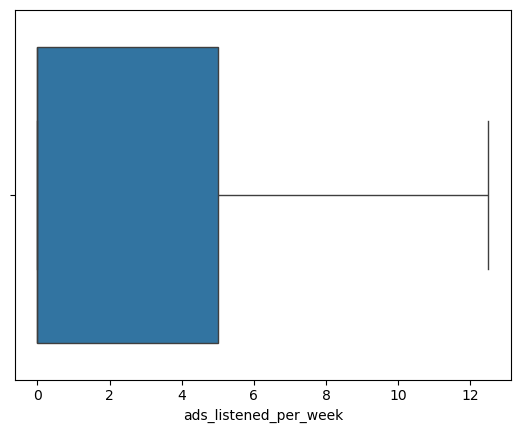

In [17]:
sns.boxplot(data = data, x = 'ads_listened_per_week')
# capped outliers
# However, the dataset is still stalled towards left, thus we will look forward for log 1p transformation.

In [18]:
data['ads_listened_per_week'] = np.log(data['ads_listened_per_week']+1)

<Axes: xlabel='ads_listened_per_week'>

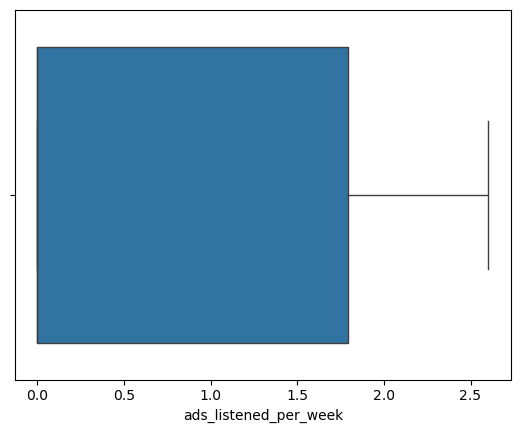

In [19]:
sns.boxplot(data = data, x = 'ads_listened_per_week')

In [20]:
import statsmodels.formula.api as sfa
from sklearn.metrics import (r2_score,mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,roc_auc_score,roc_curve,classification_report,confusion_matrix,cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sma

In [21]:
data.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

In [29]:
data.head(4)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,2.60269,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0.00000,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0.00000,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0.00000,1,0


## Regression Analysis
1. Dependent variable - 'is_churned'
2. Independent variable - other than dependent variable everything.
**********************************************
We will look for the analysis that the number of songs played if has any causality on any of the variable data given in the dataset.

In [34]:
predictor_variables = ['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week','offline_listening']

In [38]:
y = data['is_churned']
x = data[predictor_variables]

In [39]:
y.value_counts(normalize=True)
# imbalanced data, hence there is pressing need to balance before training any model.

is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64

In [40]:
x_c = sma.add_constant(x)

In [41]:
model = sma.Logit(y,x_c).fit()

Optimization terminated successfully.
         Current function value: 0.571468
         Iterations 5


In [43]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_churned   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7993
Method:                           MLE   Df Model:                            6
Date:                Mon, 17 Nov 2025   Pseudo R-squ.:               0.0007142
Time:                        16:59:44   Log-Likelihood:                -4571.7
converged:                       True   LL-Null:                       -4575.0
Covariance Type:            nonrobust   LLR p-value:                    0.3660
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.2990      0.819     -2.806      0.005      -3.905      -0.693
age                       0.0008      0.002      0.375      0.708      -0.003       0.005
listening_time           -0.0002      0.000     -0.635      0.526      -0.001       0.000
songs_played_per_day      0.0007      0.001      0.783      0.433      -0.001       0.002
skip_rate                 0.2182      0.147      1.482      0.138      -0.070       0.507
ads_listened_per_week     0.4314      0.318      1.359      0.174      -0.191       1.054
offline_listening         1.1638      0.811      1.435      0.151      -0.426       2.753
=========================================================================================
"""

In [45]:
# None of the predictor variables is significantly affecting the log odds of being churned, same holds true for overall model. Conclusive analysis is thus impossible.

## Predictive Modelling

In [62]:
model_lr = LogisticRegression(class_weight='balanced')

In [63]:
model_lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [64]:
ypred_lr_s = model_lr.predict_proba(x_test)[:,1]
ypred_lr_h = model_lr.predict(x_test)

In [65]:
ypred_lr_h,ypred_lr_s

(array([1, 1, 0, ..., 1, 0, 1], dtype=int64),
 array([0.52456735, 0.50666446, 0.45412773, ..., 0.50275217, 0.49427546,
        0.51423506]))

In [47]:
from sklearn.model_selection import train_test_split

In [50]:
x_train,x_test,y_train,y_test = train_test_split(x_c,y,train_size= 0.6,stratify=y,random_state=2)

In [60]:
def model_performance(ytest,ypred_h,ypred_s):
    print('Classification Report \n',classification_report(ytest,ypred_h))
    print('Confusion Matrix \n',confusion_matrix(ytest,ypred_h))
    print('Cohen Kappa Score',cohen_kappa_score(ytest,ypred_h))
    fpr,tpr,threshold = roc_curve(ytest,ypred_s)
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], ls = '--')
    plt.xlabel('fpr')
    plt.ylabel('tpr')
    plt.title(f'Roc auc score:{round(roc_auc_score(ytest,ypred_s),2)}')
    plt.tight_layout()
    plt.show()

Classification Report 
               precision    recall  f1-score   support

           0       0.74      0.44      0.55      2372
           1       0.26      0.57      0.36       828

    accuracy                           0.47      3200
   macro avg       0.50      0.50      0.45      3200
weighted avg       0.62      0.47      0.50      3200

Confusion Matrix 
 [[1033 1339]
 [ 355  473]]
Cohen Kappa Score 0.004869910532282917


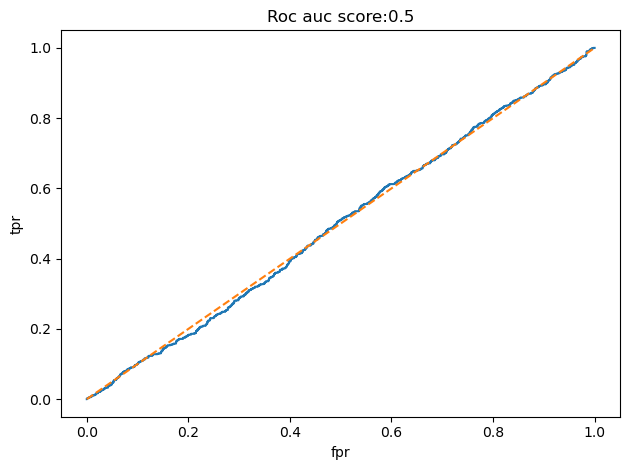

In [66]:
model_performance(y_test,ypred_lr_h,ypred_lr_s)

In [67]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
model_knn = KNeighborsClassifier(n_neighbors=7,metric = 'euclidean')

In [71]:
model_knn.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

In [72]:
ypred_knn_s = model_knn.predict_proba(x_test)[:,1]
ypred_knn_h = model_knn.predict(x_test)

Classification Report 
               precision    recall  f1-score   support

           0       0.74      0.91      0.82      2372
           1       0.25      0.08      0.12       828

    accuracy                           0.70      3200
   macro avg       0.49      0.50      0.47      3200
weighted avg       0.61      0.70      0.64      3200

Confusion Matrix 
 [[2169  203]
 [ 761   67]]
Cohen Kappa Score -0.005974276695102976


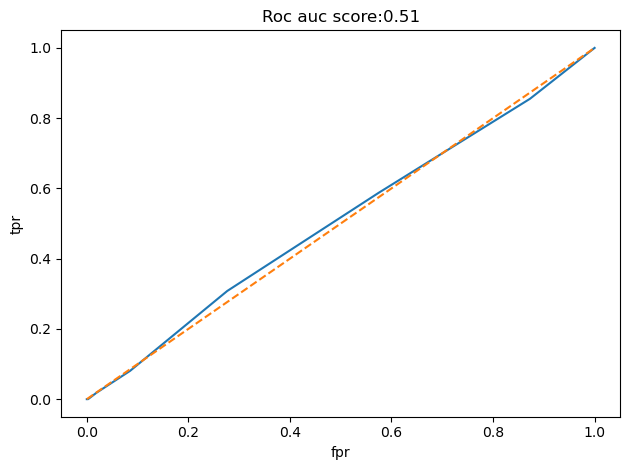

In [73]:
model_performance(y_test,ypred_knn_h,ypred_knn_s)

In [74]:
from xgboost import XGBClassifier

In [75]:
model_xgb = XGBClassifier()

In [76]:
model_xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
ypred_xgb_s = model_xgb.predict_proba(x_test)[:,1]
ypred_xgb_h = model_xgb.predict(x_test)

Classification Report 
               precision    recall  f1-score   support

           0       0.74      0.91      0.82      2372
           1       0.26      0.09      0.14       828

    accuracy                           0.70      3200
   macro avg       0.50      0.50      0.48      3200
weighted avg       0.62      0.70      0.64      3200

Confusion Matrix 
 [[2155  217]
 [ 751   77]]
Cohen Kappa Score 0.0019126570466719839


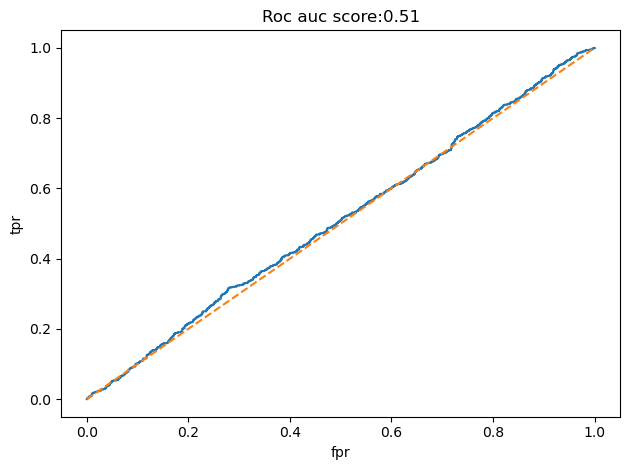

In [79]:
model_performance(y_test,ypred_xgb_h,ypred_xgb_s)

In [ ]:
# Almost all the models perform at the same level on a poor ground this is because of the data that is being provided. 
# So, no model can be called superior, however because of prime callibre of XGBoost, we decide to finally deploy the XGBoost model.